### PH464/564: Scientific Computing II
___

# Homework 3
### Due: Mon, Oct 20th at 11:59pm Pacific
---

The purpose of this assignment is to get exercise on some basic sampling skills, focusing on rejection and importance sampling.

Take the following probability density function:

$p(x) = 0.164\exp{\left(-\frac{(x-10)^4}{2\cdot 8^2}\right)}$

1. Use _rejection sampling_ to draw 1000 samples from this distribution.  Show that the samples you've drawn are correctly distributed according to this probability density function.

2. Use _importance sampling_ to estimate the expectation value of $x$, and compare it to the mean of the samples you drew in part 1.

3. Calculate the expectation value of $x^2$.

## Grad students:

4. Revisit the importance sampling example from the Intro to Sampling notebook from class.  There we demonstrated the use of importance sampling to estimate the expectation value of some function of our random variable.  We could also use the weights we computed to probabilistically choose samples from the sampling distribution to keep, in an effort to "reweigh" the sampling distribution to correspond to the target distribution.  Try to implement this, and see if your resampled distribution's histogram matches the target distribution's probability density function.

## Problem 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import scipy.stats as stats

In [2]:
matplotlib.rcParams['font.family'] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
font = {'size' : 12}
plt.rc('font', **font)

In [3]:
## basic MC
def p(x):
    return 0.164 * np.exp(-(x - 10) ** 4 / (2 * 8 ** 2))

def g(x):
    return np.ones_like(x)

def MC(n, xmin, xmax, k):
    samples = []
    i = 0
    
    while i < n:
        x = np.random.uniform(xmin, xmax)
        y = np.random.uniform(0, k*g(x))
        
        if y <= p(x):
            samples.append(x)
            
        i = len(samples)
            
    return np.array(samples)

In [4]:
xmin = 0
xmax = 20
x = np.linspace(xmin, xmax, 1000)
k = max(p(x)/g(x))

In [5]:
n = 1000
s = MC(n, xmin, xmax, k)
print("{} samples drawn from target distribution".format(len(s)))

1000 samples drawn from target distribution


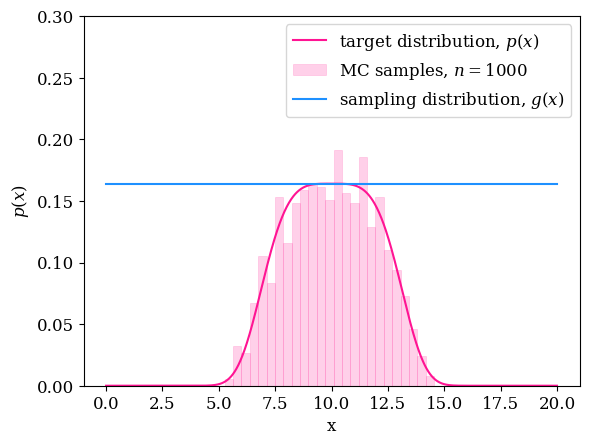

In [6]:
plt.plot(x, p(x), label=r'target distribution, $p(x)$', color='deeppink')
plt.hist(s, bins=25, alpha=0.2, color='deeppink', density=True, edgecolor='deeppink', lw=0.5, label=r'MC samples, $n=1000$');
plt.plot(x, k*g(x), label=r'sampling distribution, $g(x)$', color='dodgerblue')

plt.ylim(0,0.3)
plt.xlabel('x')
plt.ylabel('$p(x)$')
plt.legend()

plt.show()

## Problem 2

In [7]:
## importance sampling
print(f'Mean of MC samples: {np.mean(s)}; standard deviation of MC samples: {np.std(s)}')

Mean of MC samples: 9.969310860745138; standard deviation of MC samples: 1.9716057656567305


In [24]:
X_g = stats.distributions.norm(loc=10, scale=3)
S = 1000
x_gs = X_g.rvs(S)
ws = p(x_gs)/(1.5 * X_g.pdf(x_gs))
E_x = np.sum(x_gs * ws)/np.sum(ws)
print(f'Expectation value of x: {E_x}')

Expectation value of x: 9.984059205121476


In [25]:
p_diff = np.abs((np.mean(s)-E_x)/np.mean(s))
print(f'Percent difference: {round(p_diff * 100, 3)}%')

Percent difference: 0.148%


## Problem 3

In [26]:
## expectation of x^2
E_x2 = np.sum(x_gs ** 2 * ws)/np.sum(ws)
print(f'Expectation value of x^2: {E_x2}')

Expectation value of x^2: 103.39359475834046


## Problem 4

In [27]:
## use weights from importance sampling to get target distribution
w_max = np.max(ws)
S_w = np.random.uniform(0, w_max, S) < ws
print("{} samples drawn from target distribution".format(len(x_gs[S_w])))

764 samples drawn from target distribution


In [28]:
def pdf(x, mu=10, sigma=2.):
    return 1/np.sqrt(2*np.pi*sigma**2) * np.exp(-(x - mu)**2/(2*sigma**2))

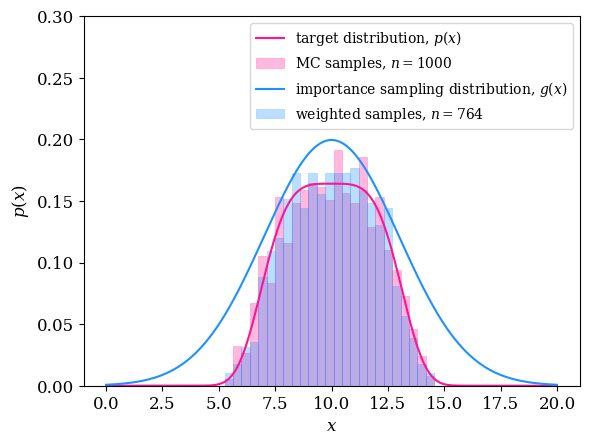

In [30]:
plt.plot(x, p(x), label=r'target distribution, $p(x)$', color='deeppink')
data, bins, patches = plt.hist(s, bins=25, alpha=0.3, color='deeppink', density=True, edgecolor='deeppink', lw=0.5, label=r'MC samples, $n=1000$');
plt.plot(x, 1.5 * pdf(x, 10, 3), color='dodgerblue', label=r'importance sampling distribution, $g(x)$')
plt.hist(x_gs[S_w], bins=bins, alpha=0.3, color='dodgerblue', density=True, edgecolor='dodgerblue', lw=0.5, label=fr'weighted samples, $n={len(x_gs[S_w])}$');

plt.ylim(0, 0.3)
plt.xlabel('$x$')
plt.ylabel('$p(x)$')
plt.legend(fontsize='small')

plt.show()